In [7]:
import numpy as np

import sys
sys.path.append("..")
import data_generation
import torch
import matplotlib.pyplot as plt
import ml_solver

# 1D Gaussian Random Field

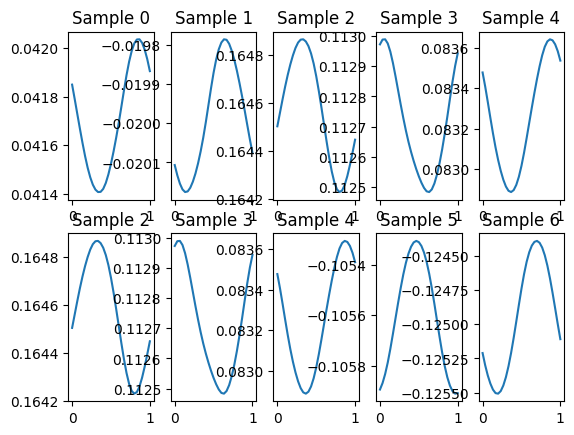

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
grf = data_generation.GaussianRandomField(dim=1, num_samples=31, alpha=1.0, beta=1.0, gamma=4.0, device = device)
a = grf.generate(2)
f = grf.generate(2)
# plt.plot(np.linspace(0, 1, 31), x[0])
grf.visualize()

In [9]:
# Testing DeepONet for just forcing function
onet = ml_solver.DeepONet(N = 31, dim = 1, coef = False).to(device)
print(f.shape)
output = onet(f[:, None, :])
print(output.shape)

# Testing DeepONet for coefficient and forcing function
onet2 = ml_solver.DeepONet(N = 31, dim = 1, coef = True).to(device)
input = torch.cat((a[:, None, :], f[:, None, :]), dim=1)
print(input.shape)
output2 = onet2(input)
print(output2.shape)

# Testing FNO for just forcing function
fno = ml_solver.FNOforPDE(trunc_mode = 16, dim = 1, coef = False).to(device)
output3 = fno(f[:, None, :])
print(output3.shape)

fno2 = ml_solver.FNOforPDE(trunc_mode = 16, dim = 1, coef = True).to(device)
output4 = fno2(input)
print(output4.shape)

torch.Size([2, 31])
torch.Size([2, 31])
torch.Size([2, 2, 31])
torch.Size([2, 31])
torch.Size([2, 31])
torch.Size([2, 31])


In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
grf = data_generation.GaussianRandomField(dim=2, num_samples=31, alpha=1.0, beta=1.0, gamma=4.0, device = device)
a = grf.generate(2)
f = grf.generate(2)

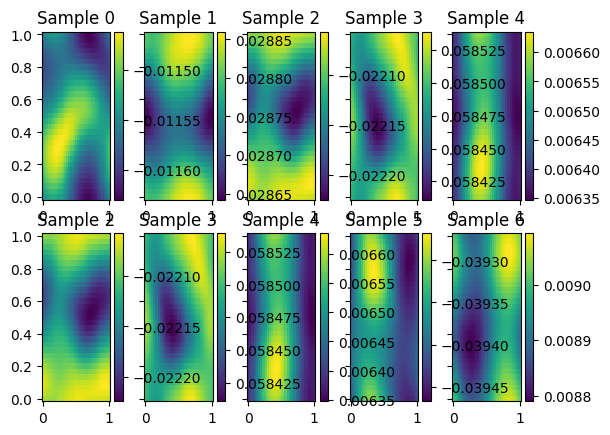

In [11]:
grf.visualize()

In [12]:
onet = ml_solver.DeepONet(N = 31, dim = 2, coef = False).to(device)
print(f.shape)
output = onet(f)
print(output.shape)

onet2 = ml_solver.DeepONet(N = 31, dim = 2, coef = True).to(device)
input = torch.cat((a[:, None, :], f[:, None, :]), dim=1)
print(input.shape)
output2 = onet2(input)
print(output2.shape)

fno = ml_solver.FNOforPDE(trunc_mode = 16, dim = 2, coef = False).to(device)
output3 = fno(f[:, None, :, :])
print(output3.shape)

fno2 = ml_solver.FNOforPDE(trunc_mode = 16, dim = 2, coef = True).to(device)
output4 = fno2(input)
print(output4.shape)

torch.Size([2, 31, 31])
torch.Size([2, 31, 31])
torch.Size([2, 2, 31, 31])
torch.Size([2, 31, 31])
torch.Size([2, 31, 31])
torch.Size([2, 31, 31])
